# Week 5 - MobileNetV2 Transfer Learning, Phase 1 (Feature Extraction)

**Project:** Image-Based Fruit Ripeness Classification (STU141830)

**Strategy.** Load MobileNetV2 with ImageNet weights (`include_top=False`), freeze the entire convolutional base, attach a new classifier head (`GlobalAveragePooling2D → Dropout → Dense(9, softmax)`), and train only the head. Phase 2 (fine-tuning the top blocks of the base with a smaller learning rate) is scheduled for Week 6.

**Reproducibility:** `SEED = 42` applied to `random`, `numpy`, `tensorflow`, dropout, and augmentation layers.

**Pre-processing note.** MobileNetV2 expects pixel values in `[-1, 1]` via `tf.keras.applications.mobilenet_v2.preprocess_input`. Do **not** apply `1./255` rescaling - that produces a range mismatch with the pre-trained weights.


In [28]:
# Imports and reproducibility
import os
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import matplotlib.pyplot as plt

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow:', tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print('GPU available:', bool(gpus), gpus)


TensorFlow: 2.11.0
GPU available: False []


In [29]:
# Build dataset_splits/ from results/data_split.csv (idempotent).
# The original dataset/ (used by the baseline CNN) is NEVER modified: images are copied, not moved.
import shutil

PROJECT_ROOT = Path.cwd().parent           # notebook lives in notebooks/
SPLITS_DIR = PROJECT_ROOT / 'dataset_splits'
SPLIT_CSV = PROJECT_ROOT / 'results' / 'data_split.csv'

if SPLITS_DIR.exists():
    print(f'dataset_splits/ already exists -> skipping build ({SPLITS_DIR})')
else:
    assert SPLIT_CSV.exists(), f'Missing split CSV: {SPLIT_CSV}'
    split_df = pd.read_csv(SPLIT_CSV)
    copied, missing = {}, []
    for row in split_df.itertuples(index=False):
        rel = str(row.path).replace('\\', '/')        # CSV uses Windows backslashes
        src = PROJECT_ROOT / rel
        if not src.exists():
            missing.append(rel)
            continue
        dst_dir = SPLITS_DIR / row.split / row.class_name
        dst_dir.mkdir(parents=True, exist_ok=True)
        dst = dst_dir / src.name
        if not dst.exists():
            shutil.copy2(src, dst)
        copied[row.split] = copied.get(row.split, 0) + 1
    print('Built dataset_splits/ ->', copied)
    if missing:
        print(f'WARNING: {len(missing)} source files listed in CSV are missing, e.g. {missing[:3]}')


dataset_splits/ already exists -> skipping build (d:\Arden Uni\IV Year (Level 6)\Final Project\week1\fruit_ripeness\dataset_splits)


In [30]:
# Paths and config
PROJECT_ROOT = Path.cwd().parent  # notebook lives in notebooks/
DATASET_DIR = PROJECT_ROOT / 'dataset_splits'  # split-structured copy built above (original dataset/ untouched)
SAVED_MODELS_DIR = PROJECT_ROOT / 'saved_models'
RESULTS_DIR = PROJECT_ROOT / 'results'
SAVED_MODELS_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 25
LR = 1e-3
DROPOUT = 0.2
NUM_CLASSES = 9
MODEL_NAME = 'mobilenet_phase1'

# Verify dataset structure
for split in ('train', 'val', 'test'):
    split_dir = DATASET_DIR / split
    assert split_dir.exists(), f'Missing directory: {split_dir}'
    classes = sorted([p.name for p in split_dir.iterdir() if p.is_dir()])
    print(f'{split:5s}: {len(classes)} classes -> {classes}')

print('\nSave path:', SAVED_MODELS_DIR / f'{MODEL_NAME}_best.h5')


train: 9 classes -> ['apple_overripe', 'apple_ripe', 'apple_unripe', 'banana_overripe', 'banana_ripe', 'banana_unripe', 'pear_overripe', 'pear_ripe', 'pear_unripe']
val  : 9 classes -> ['apple_overripe', 'apple_ripe', 'apple_unripe', 'banana_overripe', 'banana_ripe', 'banana_unripe', 'pear_overripe', 'pear_ripe', 'pear_unripe']
test : 9 classes -> ['apple_overripe', 'apple_ripe', 'apple_unripe', 'banana_overripe', 'banana_ripe', 'banana_unripe', 'pear_overripe', 'pear_ripe', 'pear_unripe']

Save path: d:\Arden Uni\IV Year (Level 6)\Final Project\week1\fruit_ripeness\saved_models\mobilenet_phase1_best.h5


In [31]:
# Raw data loaders (uint8 -> float32 in [0, 255])
train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR / 'train',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=True,
    seed=SEED
)
val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR / 'val',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False
)

class_names = train_ds_raw.class_names
print('\nClasses:', class_names)
assert len(class_names) == NUM_CLASSES, f'Expected {NUM_CLASSES} classes, got {len(class_names)}'

# Save class names for the evaluation notebook (Week 6/7)
with open(RESULTS_DIR / 'class_names.json', 'w') as f:
    json.dump(class_names, f, indent=2)


Found 315 files belonging to 9 classes.
Found 63 files belonging to 9 classes.

Classes: ['apple_overripe', 'apple_ripe', 'apple_unripe', 'banana_overripe', 'banana_ripe', 'banana_unripe', 'pear_overripe', 'pear_ripe', 'pear_unripe']


In [32]:
# Augmentation (training only) + MobileNetV2-specific preprocessing
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal', seed=SEED),
    layers.RandomRotation(0.1, seed=SEED),
    layers.RandomZoom(0.1, seed=SEED),
], name='data_augmentation')

AUTOTUNE = tf.data.AUTOTUNE

def prep_train(x, y):
    # Augment on [0, 255], then scale to [-1, 1] via preprocess_input.
    x = data_augmentation(x, training=True)
    x = preprocess_input(x)
    return x, y

def prep_val(x, y):
    x = preprocess_input(x)
    return x, y

train_ds = train_ds_raw.map(prep_train, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
val_ds = val_ds_raw.map(prep_val, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

# Sanity check: pixel range after preprocessing must be roughly [-1, 1]
for x_batch, y_batch in train_ds.take(1):
    print(f'Batch shape: {x_batch.shape}')
    print(f'Pixel range after preprocess_input: [{x_batch.numpy().min():.3f}, {x_batch.numpy().max():.3f}]')
    print(f'Label shape: {y_batch.shape}')


Batch shape: (32, 224, 224, 3)
Pixel range after preprocess_input: [-1.000, 1.000]
Label shape: (32, 9)


In [33]:
# Build MobileNetV2 + custom classifier head
base_model = MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # freeze entire base (feature extraction)

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(name='gap'),
    layers.Dropout(DROPOUT, seed=SEED, name='dropout'),
    layers.Dense(NUM_CLASSES, activation='softmax', name='predictions'),
], name='mobilenetv2_phase1')

model.compile(
    optimizer=optimizers.Adam(learning_rate=LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

trainable = int(sum(tf.keras.backend.count_params(w) for w in model.trainable_weights))
non_trainable = int(sum(tf.keras.backend.count_params(w) for w in model.non_trainable_weights))
print(f'\nTrainable params:     {trainable:,}')
print(f'Non-trainable params: {non_trainable:,}')
print(f'Total params:         {trainable + non_trainable:,}')


Model: "mobilenetv2_phase1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mobilenetv2_1.00_224 (Funct  (None, 7, 7, 1280)       2257984   
 ional)                                                          
                                                                 
 gap (GlobalAveragePooling2D  (None, 1280)             0         
 )                                                               
                                                                 
 dropout (Dropout)           (None, 1280)              0         
                                                                 
 predictions (Dense)         (None, 9)                 11529     
                                                                 
Total params: 2,269,513
Trainable params: 11,529
Non-trainable params: 2,257,984
_________________________________________________________________

Trainable params:     11,529
Non

In [34]:
# Callbacks: best-checkpoint, early stopping, LR reduction on plateau
ckpt_path = SAVED_MODELS_DIR / f'{MODEL_NAME}_best.h5'

cb_list = [
    callbacks.ModelCheckpoint(
        filepath=str(ckpt_path),
        monitor='val_loss',
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    ),
    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]


In [35]:
# Train
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=cb_list,
    verbose=1
)


Epoch 1/25
10/10 [==============================] - ETA: 0s - loss: 2.0928 - accuracy: 0.2635
Epoch 1: val_loss improved from inf to 1.55736, saving model to d:\Arden Uni\IV Year (Level 6)\Final Project\week1\fruit_ripeness\saved_models\mobilenet_phase1_best.h5
10/10 [==============================] - 11s 573ms/step - loss: 2.0928 - accuracy: 0.2635 - val_loss: 1.5574 - val_accuracy: 0.3492 - lr: 0.0010
Epoch 2/25
10/10 [==============================] - ETA: 0s - loss: 1.1957 - accuracy: 0.6032
Epoch 2: val_loss improved from 1.55736 to 1.04214, saving model to d:\Arden Uni\IV Year (Level 6)\Final Project\week1\fruit_ripeness\saved_models\mobilenet_phase1_best.h5
10/10 [==============================] - 12s 913ms/step - loss: 1.1957 - accuracy: 0.6032 - val_loss: 1.0421 - val_accuracy: 0.6667 - lr: 0.0010
Epoch 3/25
10/10 [==============================] - ETA: 0s - loss: 0.8690 - accuracy: 0.7111
Epoch 3: val_loss improved from 1.04214 to 0.86520, saving model to d:\Arden Uni\IV Year

In [36]:
# Persist training history (JSON) and append per-epoch rows to results.csv
hist_dict = {k: [float(v) for v in vals] for k, vals in history.history.items()}
with open(RESULTS_DIR / f'{MODEL_NAME}_history.json', 'w') as f:
    json.dump(hist_dict, f, indent=2)

hist_df = pd.DataFrame(history.history)
hist_df.insert(0, 'epoch', range(1, len(hist_df) + 1))
hist_df.insert(0, 'phase', 'train')
hist_df.insert(0, 'model', MODEL_NAME)

results_csv = RESULTS_DIR / 'results.csv'

if results_csv.exists():
    existing = pd.read_csv(results_csv)
    # Idempotent: drop any prior phase1 train rows so re-runs don't duplicate.
    if 'model' in existing.columns and 'phase' in existing.columns:
        mask = ~((existing['model'] == MODEL_NAME) & (existing['phase'] == 'train'))
        existing = existing[mask]
    out_df = pd.concat([existing, hist_df], ignore_index=True, sort=False)
else:
    out_df = hist_df

out_df.to_csv(results_csv, index=False)
print(f'Logged {len(hist_df)} rows to {results_csv}')
print(f'Saved history JSON: {RESULTS_DIR / f"{MODEL_NAME}_history.json"}')


Logged 25 rows to d:\Arden Uni\IV Year (Level 6)\Final Project\week1\fruit_ripeness\results\results.csv
Saved history JSON: d:\Arden Uni\IV Year (Level 6)\Final Project\week1\fruit_ripeness\results\mobilenet_phase1_history.json


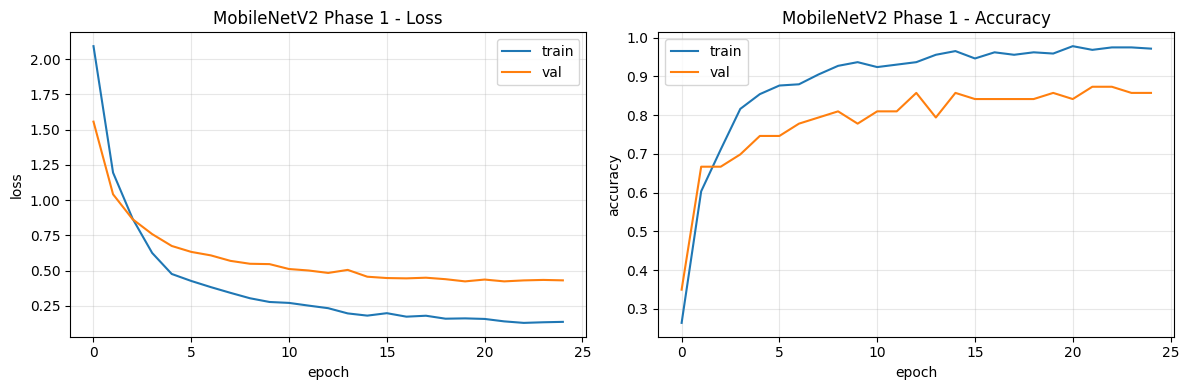

Saved plot: d:\Arden Uni\IV Year (Level 6)\Final Project\week1\fruit_ripeness\results\mobilenet_phase1_training_curves.png


In [37]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'], label='train', linewidth=1.5)
axes[0].plot(history.history['val_loss'], label='val', linewidth=1.5)
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('loss')
axes[0].set_title('MobileNetV2 Phase 1 - Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['accuracy'], label='train', linewidth=1.5)
axes[1].plot(history.history['val_accuracy'], label='val', linewidth=1.5)
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('accuracy')
axes[1].set_title('MobileNetV2 Phase 1 - Accuracy')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plot_path = RESULTS_DIR / f'{MODEL_NAME}_training_curves.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved plot: {plot_path}')


In [38]:
# Final summary
val_losses = history.history['val_loss']
val_accs = history.history['val_accuracy']
best_idx = int(np.argmin(val_losses))
best_epoch = best_idx + 1

print('=' * 60)
print('PHASE 1 TRAINING SUMMARY')
print('=' * 60)
print(f'Model:               {MODEL_NAME}')
print(f'Total epochs run:    {len(val_losses)}')
print(f'Best epoch:          {best_epoch} (min val_loss)')
print(f'Best val_loss:       {val_losses[best_idx]:.4f}')
print(f'Best val_accuracy:   {val_accs[best_idx]:.4f} ({val_accs[best_idx]*100:.2f}%)')
print(f'Train_loss at best:  {history.history["loss"][best_idx]:.4f}')
print(f'Train_acc at best:   {history.history["accuracy"][best_idx]:.4f}')
print(f'Saved model:         {ckpt_path}')
print('=' * 60)
print('Next step (Week 6): Phase 2 fine-tuning (unfreeze top blocks, LR=1e-5).')


PHASE 1 TRAINING SUMMARY
Model:               mobilenet_phase1
Total epochs run:    25
Best epoch:          20 (min val_loss)
Best val_loss:       0.4242
Best val_accuracy:   0.8571 (85.71%)
Train_loss at best:  0.1618
Train_acc at best:   0.9587
Saved model:         d:\Arden Uni\IV Year (Level 6)\Final Project\week1\fruit_ripeness\saved_models\mobilenet_phase1_best.h5
Next step (Week 6): Phase 2 fine-tuning (unfreeze top blocks, LR=1e-5).
